# Notebook 02 - Preprocessing & Clinical Narrative Construction

# Environment Setup and Global Configuration

This section initialises the computational environment and loads all required dependencies for the data processing workflow. Establishing a consistent environment at the beginning of the analysis ensures reproducibility, portability, and transparency across experiments.

The following steps are performed:

- The project root directory is added to the Python path to enable importing local modules without requiring package installation.
- Core scientific computing libraries are imported, including **pandas** and **NumPy** for data manipulation and numerical operations.
- Non-critical warnings are suppressed to improve notebook readability during execution.
- Utility libraries such as **tqdm** are loaded to provide progress monitoring for large-scale iterative operations.
- **Matplotlib** is configured with consistent visualisation settings to ensure uniform figure quality throughout the notebook.
- Centralised configuration parameters are imported from the project configuration file, including:
  - Data directory paths for hospital and ICU modules
  - Output directories for processed datasets and plots
  - The readmission labelling window used in the experimental design

Finally, key runtime parameters are printed to confirm the dataset version, label definition window, and output location for the labelled dataset.

Centralising configuration and environment setup in this manner reduces the risk of inconsistencies and facilitates reproducible research practices.

In [1]:
# Add Project Root Directory
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Data Manipulation Libraries
import pandas as pd
import numpy as np
import gzip

# Regular Expressions and Warning Control
import re, warnings
warnings.filterwarnings('ignore')

# Progress Tracking Utility
from tqdm import tqdm

# Visualisation Library
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Project Configuration Paths and Parameters
from config import (
    HOSP_DIR, ICU_DIR,
    PROCESSED_DIR, LABELLED_DATASET,
    PLOTS_DIR, READMISSION_WINDOW_DAYS, 
    RANDOM_STATE, SUBSET_PATIENTS
)

# Create Preprocessing Plot Save Directory
PREPROCESSING_PLT = PLOTS_DIR / "preprocessing"
PREPROCESSING_PLT.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})


# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F']

### Data Loading And Initial Preprocessing

This section loads the core MIMIC-IV hospital and ICU tables required for cohort construction and feature extraction. Multiple datasets are imported, including patient demographics, hospital admissions, diagnoses, prescriptions, laboratory measurements, and ICU stay information. Additionally, the Outpatient Medical Record (OMR) table is incorporated to provide physiological measurements such as body mass index and blood pressure.

To ensure temporal consistency across datasets, relevant timestamp variables are converted into datetime format. A schema validation check is also performed to confirm compatibility with the expected MIMIC-IV version, preventing downstream errors due to structural differences between dataset releases.

Finally, basic dataset statistics are displayed to verify successful data loading and to provide an overview of cohort scale.

In [2]:
# Core Hospital Tables
patients = pd.read_csv(f'{HOSP_DIR}/patients.csv.gz')
admissions = pd.read_csv(f'{HOSP_DIR}/admissions.csv.gz')
d_icd_diag = pd.read_csv(f'{HOSP_DIR}/d_icd_diagnoses.csv.gz')
d_labitems = pd.read_csv(f'{HOSP_DIR}/d_labitems.csv.gz')
icustays = pd.read_csv(f'{ICU_DIR}/icustays.csv.gz')
omr = pd.read_csv(f'{HOSP_DIR}/omr.csv.gz')

# Subset: Sample Fixed Patient Cohort For Memory Efficiency
if SUBSET_PATIENTS is not None:
    sampled_ids = (
        patients['subject_id']
        .sample(n=min(SUBSET_PATIENTS, len(patients)), random_state=42)
        .values
    )
    patients   = patients[patients['subject_id'].isin(sampled_ids)].copy()
    admissions = admissions[admissions['subject_id'].isin(sampled_ids)].copy()
    icustays   = icustays[icustays['subject_id'].isin(sampled_ids)].copy()
    omr        = omr[omr['subject_id'].isin(sampled_ids)].copy()
    print(f'Subset Applied  : {len(patients):,} patients, {len(admissions):,} admissions')
else:
    sampled_ids = patients['subject_id'].values
    print('Full Dataset    : No subset applied')

subset_hadm = set(admissions['hadm_id'].unique())

# Filtered Hospital Tables
diagnoses     = pd.read_csv(f'{HOSP_DIR}/diagnoses_icd.csv.gz')
diagnoses     = diagnoses[diagnoses['hadm_id'].isin(subset_hadm)].copy()

prescriptions = pd.read_csv(f'{HOSP_DIR}/prescriptions.csv.gz')
prescriptions = prescriptions[prescriptions['hadm_id'].isin(subset_hadm)].copy()

# Laboratory Events  
_lab_count    = {}
_abnorm_count = {}

for chunk in tqdm(
        pd.read_csv(
            f'{HOSP_DIR}/labevents.csv.gz',
            usecols=['hadm_id', 'itemid', 'flag'],
            compression='gzip',
            chunksize=500_000),
        desc='labevents chunks', unit='chunk'):

    chunk = chunk[chunk['hadm_id'].isin(subset_hadm)].dropna(subset=['hadm_id'])
    if len(chunk) == 0:
        continue
    chunk['hadm_id'] = chunk['hadm_id'].astype(int)
    chunk['is_abnormal'] = (
        chunk['flag'].fillna('').str.strip().str.lower()
        .isin(['abnormal', 'delta'])
    ).astype(int)
    grp = chunk.groupby('hadm_id').agg(
        n=('itemid', 'count'), n_abn=('is_abnormal', 'sum'))
    for hadm_id, row in grp.iterrows():
        _lab_count[hadm_id]    = _lab_count.get(hadm_id, 0)    + int(row['n'])
        _abnorm_count[hadm_id] = _abnorm_count.get(hadm_id, 0) + int(row['n_abn'])

lab_summary = pd.DataFrame({
    'hadm_id'       : list(_lab_count.keys()),
    'lab_count'     : list(_lab_count.values()),
    'abnormal_count': [_abnorm_count.get(h, 0) for h in _lab_count],
})
lab_summary['pct_abnormal'] = (
    lab_summary['abnormal_count'] / lab_summary['lab_count'] * 100
).round(1)
del _lab_count, _abnorm_count
print(f'Lab Summary Computed For {len(lab_summary):,} Admissions')

# Convert Temporal Columns To Datetime Format
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
patients['dod'] = pd.to_datetime(patients['dod'], errors='coerce')
prescriptions['starttime'] = pd.to_datetime(prescriptions['starttime'], errors='coerce')


# Validate Dataset Schema Version 
assert 'loinc_code' not in d_labitems.columns, \
    'Unexpected loinc_code column -- check dataset version'


# Display Dataset Summary Statistics
print('All tables loaded.')
print(f'Admissions : {len(admissions):,}')
print(f'Patients : {len(patients):,}')
print(f'OMR records : {len(omr):,}')

Subset Applied  : 20,000 patients, 29,597 admissions


labevents chunks: 317chunk [08:52,  1.68s/chunk]


Lab Summary Computed For 24,277 Admissions
All tables loaded.
Admissions : 29,597
Patients : 20,000
OMR records : 416,696


### Readmission Label Construction And Cohort Filtering

This section constructs the primary outcome variable representing 30-day hospital readmission. Admissions are first chronologically ordered at the patient level to enable identification of subsequent hospital encounters. Mortality information is incorporated by merging patient date-of-death records, allowing exclusion of cases where readmission is not clinically observable.

Two mortality indicators are defined: in-hospital death and death within 30 days following discharge. These adjustments ensure that readmission labels are not confounded by competing risk from early mortality. Length of stay is also calculated to support potential downstream feature engineering.

The readmission label is then generated based on whether a subsequent admission occurs within the predefined temporal window, conditional on patient survival. Admissions involving in-hospital mortality are excluded from the modelling cohort to maintain outcome validity.

Finally, descriptive statistics and a visualisation of label distribution are produced to verify cohort composition and assess class imbalance.

Label distribution (excluding in-hospital deaths):
  Not readmitted (0):  23,324  (80.5%)
  Readmitted (1):   5,646  (19.5%)

Excluded (died in hospital)  : 627
Label-corrected (died <30d)  : 711


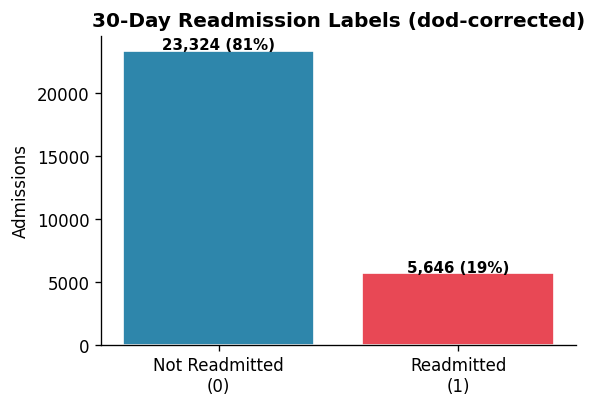

In [3]:
# Sort Admissions Chronologically Within Each Patient
adm = admissions.sort_values(['subject_id', 'admittime']).copy()


# Merge Date Of Death Information
adm = adm.merge(
    patients[['subject_id', 'dod']],
    on='subject_id',
    how='left'
)


# Flag In-Hospital Mortality
if 'hospital_expire_flag' in adm.columns:
    adm['died_in_hospital'] = (
        adm['hospital_expire_flag']
        .fillna(0)
        .astype(int)
    )
else:
    adm['died_in_hospital'] = 0


# Flag Post-Discharge Death Within 30 Days Using Date Of Death
adm['died_within_30d'] = (
    adm['dod'].notna() &
    (
        (adm['dod'] - adm['dischtime'])
        .dt.total_seconds() / 86400
    ).between(0, 30)
).astype(int)


# Calculate Length Of Stay In Days
adm['los_days'] = (
    (adm['dischtime'] - adm['admittime'])
    .dt.total_seconds() / 86400
)


# Identify Next Admission Timing Per Patient
adm['next_admittime'] = (
    adm.groupby('subject_id')['admittime']
    .shift(-1)
)

adm['days_to_next'] = (
    (adm['next_admittime'] - adm['dischtime'])
    .dt.total_seconds() / 86400
)


# Construct 30-Day Readmission Label With Mortality Correction
adm['readmission_30d'] = (
    adm['days_to_next'].between(0, READMISSION_WINDOW_DAYS) &
    (adm['died_in_hospital'] == 0) &
    (adm['died_within_30d'] == 0)
).astype(int).fillna(0).astype(int)


# Exclude Admissions With In-Hospital Mortality
adm_alive = (
    adm[adm['died_in_hospital'] == 0]
    .copy()
)


# Display Label Distribution
vc = adm_alive['readmission_30d'].value_counts()

print('Label distribution (excluding in-hospital deaths):')

for k, v in vc.items():
    lbl = 'Readmitted (1)' if k == 1 else 'Not readmitted (0)'
    print(
        f'  {lbl}: {v:>7,}  '
        f'({v / len(adm_alive) * 100:.1f}%)'
    )


# Display Mortality Exclusion Statistics
in_hosp_excl = adm['died_in_hospital'].sum()
dod30_excl   = adm['died_within_30d'].sum()

print(f'\nExcluded (died in hospital)  : {in_hosp_excl:,}')
print(f'Label-corrected (died <30d)  : {dod30_excl:,}')


# Visualise Readmission Label Distribution
fig = plt.figure(figsize=(5, 3.5))

gs = gridspec.GridSpec(
    1,
    1,
    figure=fig
)

ax1 = fig.add_subplot(gs[0])

bars = ax1.bar(
    ['Not Readmitted\n(0)', 'Readmitted\n(1)'],
    [vc.get(0, 0), vc.get(1, 0)],
    color=[PALETTE[0], PALETTE[1]],
    edgecolor='white'
)

for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{val:,} ({val / len(adm_alive) * 100:.0f}%)',
        ha='center',
        fontweight='bold',
        fontsize=9
    )


ax1.set_title(
    '30-Day Readmission Labels (dod-corrected)',
    fontweight='bold'
)

ax1.set_ylabel('Admissions')


# Figure Formatting And Export
plt.tight_layout()

plt.savefig(
    f'{PREPROCESSING_PLT}/pre_01_label_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Diagnosis Code Harmonisation And Text Normalisation

This section integrates diagnosis metadata with admission-level diagnosis records by merging ICD codes with their corresponding descriptive titles. Mapping structured codes to clinically interpretable text improves interpretability and enables downstream feature engineering based on diagnostic categories.

Missing descriptions are handled by substituting the original ICD code when no title is available, ensuring completeness of the textual representation. A text normalisation procedure is then applied to standardise formatting by converting strings to lowercase and removing non-alphanumeric characters. This step reduces vocabulary sparsity and improves consistency for potential natural language processing or grouping operations.

Finally, the number of unique diagnosis titles is reported to provide an overview of the diagnostic vocabulary size within the dataset.

In [4]:
# Merge Diagnosis Codes With Descriptive Titles
dx = diagnoses.merge(
    d_icd_diag[['icd_code', 'icd_version', 'long_title']],
    on=['icd_code', 'icd_version'],
    how='left'
)


# Replace Missing Titles With Original ICD Codes
dx['long_title'] = dx['long_title'].fillna(dx['icd_code'])


# Define Text Cleaning Function For Diagnosis Titles
def _clean(t):
    t = str(t).lower()
    t = re.sub(r'[^a-z0-9 ,./()-]', '', t)
    return t.strip()


# Generate Normalised Diagnosis Titles
dx['clean_title'] = dx['long_title'].apply(_clean)


# Display Diagnosis Vocabulary Size
print(
    f'Diagnosis vocabulary: '
    f'{dx["clean_title"].nunique():,} unique titles'
)

Diagnosis vocabulary: 11,958 unique titles


### Medication Name Standardisation

This section prepares prescription drug information for analysis by standardising medication names. Raw medication entries often contain variations in capitalisation, punctuation, and formatting, which can lead to artificial duplication during aggregation.

To address this, drug names are converted to lowercase, whitespace is removed, and non-alphanumeric characters are stripped to produce a normalised representation. This preprocessing step improves consistency when identifying common medications and supports downstream feature extraction based on pharmacological exposure.

Finally, the most frequently prescribed medications are displayed to provide an overview of medication usage patterns within the cohort.

In [5]:
# Standardise Medication Names
prescriptions['drug_clean'] = (
    prescriptions['drug']
    .str.lower()
    .str.strip()
    .apply(
        lambda x: re.sub(
            r'[^a-z0-9 ]',
            '',
            str(x)
        ).strip()
    )
)


# Display Most Frequent Medications
print('Top 10 medications:')

print(
    prescriptions['drug_clean']
    .value_counts()
    .head(10)
    .to_string()
)

Top 10 medications:
drug_clean
insulin                      42658
09 sodium chloride           38584
sodium chloride 09  flush    36630
potassium chloride           36364
acetaminophen                31916
furosemide                   23849
heparin                      21917
magnesium sulfate            19976
bag                          18858
5 dextrose                   18834


### Laboratory Activity And Abnormality Aggregation

This section derives admission-level laboratory utilisation features from raw laboratory event records. An abnormality indicator is first generated based on laboratory flag annotations, capturing clinically significant deviations such as abnormal or delta values.

Laboratory measurements are then aggregated at the hospital admission level to compute the total number of laboratory tests performed and the number of abnormal results observed. From these metrics, the percentage of abnormal laboratory findings is calculated, providing a summary measure of physiological instability during admission.

These aggregated features may serve as proxies for illness severity and clinical complexity in downstream predictive modelling.

In [6]:
# Lab Summary 
print(f'Lab Summary : {len(lab_summary):,} admissions')
print(lab_summary.head())

Lab Summary : 24,277 admissions
    hadm_id  lab_count  abnormal_count  pct_abnormal
0  20070925         44              13          29.5
1  20075017         79              15          19.0
2  20083129        164             101          61.6
3  20198088        186              35          18.8
4  20219031        839             476          56.7


### Outpatient Measurement Record Processing

This section extracts recent physiological measurements from the Outpatient Medical Record (OMR) table, including body mass index and weight. Temporal information is first standardised by converting available date fields into a unified datetime representation. Measurement values are also converted to numeric format to enable quantitative analysis.

A utility function is then defined to retrieve the most recent valid measurement per patient for a specified physiological parameter. This approach ensures that each patient is represented by their latest available clinical observation, which is often most relevant for predictive modelling.

Finally, the number of patients with available recent measurements is reported to assess data coverage.

In [7]:
# Convert OMR Timestamp Column To Datetime
omr['chartdate'] = pd.to_datetime(
    omr.get('chartdate', omr.get('result_time', None)),
    errors='coerce'
)

# Convert Measurement Values To Numeric Format
omr['result_value_num'] = pd.to_numeric(
    omr['result_value'],
    errors='coerce'
)


# Define Function To Extract Most Recent Measurement Per Patient
def latest_omr(result_name_pattern):
    sub = omr[
        omr['result_name']
        .str.lower()
        .str.contains(result_name_pattern, na=False)
    ].copy()

    sub = sub.dropna(subset=['result_value_num'])

    sub = (
        sub.sort_values('chartdate')
        .groupby('subject_id')
        .last()[['result_value_num']]
    )

    return sub.rename(
        columns={'result_value_num': result_name_pattern}
    )


# Extract Recent BMI And Weight Measurements
omr_bmi    = latest_omr('bmi')
omr_weight = latest_omr('weight')


# Display Measurement Availability Statistics
print(f'Patients with recent BMI : {len(omr_bmi):,}')
print(f'Patients with recent weight : {len(omr_weight):,}')

Patients with recent BMI : 8,749
Patients with recent weight : 9,446


### Feature Lookup Index Construction

This section prepares efficient lookup structures to support feature assembly at the admission and patient levels. Key clinical domains—including diagnoses, prescriptions, ICU utilisation, laboratory summaries, and outpatient physiological measurements—are transformed into dictionary-based indices keyed by admission or patient identifiers.

Creating these indices enables rapid retrieval of relevant clinical information during cohort feature generation while avoiding repeated groupby operations, thereby improving computational efficiency.

A helper function is also defined to estimate patient age at admission using anchor age and anchor year variables provided in the dataset. The function preserves the de-identification convention for patients aged over 89 years by returning a capped representation.

Finally, a confirmation message is displayed to indicate successful construction of lookup objects.

In [8]:
# Create Patient-Level Index For Fast Lookup
pt_idx = patients.set_index('subject_id')

# Build Diagnosis Lookup By Admission
dx_by_hadm = (
    dx.groupby('hadm_id')['clean_title']
    .apply(list)
    .to_dict()
)

# Build Medication Lookup By Admission
rx_by_hadm = (
    prescriptions
    .groupby('hadm_id')['drug_clean']
    .apply(lambda s: list(s.dropna().unique()))
    .to_dict()
)

# Build ICU Length Of Stay Lookup By Admission
icu_by_hadm = (
    icustays
    .groupby('hadm_id')['los']
    .sum()
    .to_dict()
)

# Build Laboratory Summary Lookup By Admission
lab_by_hadm = (
    lab_summary
    .set_index('hadm_id')
    .to_dict('index')
)


# Build Physiological Measurement Lookup By Patient
bmi_by_pt = omr_bmi['bmi'].to_dict()
wt_by_pt  = omr_weight['weight'].to_dict()


# Define Function To Estimate Age At Admission
def get_age(subject_id, admit_year):
    row = pt_idx.loc[subject_id]

    raw_age = max(
        0,
        int(row['anchor_age'])
        + (admit_year - int(row['anchor_year']))
    )
    
    if int(row['anchor_age']) == 91:
        return '91+'
    return str(raw_age)


# Confirm Lookup Construction
print('Lookup indices built.')

Lookup indices built.


### Clinical Narrative Construction

This section defines a function to generate structured clinical narratives for each hospital admission. The narrative integrates multiple data modalities—including demographics, admission history, diagnoses, medications, laboratory summaries, physiological measurements, and ICU utilisation—into a coherent textual representation.

Patient demographic attributes such as age and gender are combined with contextual information regarding prior admissions to provide temporal clinical background. Current admission details are summarised using diagnosis and medication lists, along with laboratory activity indicators and outpatient physiological measurements when available.

The resulting narrative format is designed to support downstream natural language processing or multimodal modelling approaches by transforming structured electronic health record data into interpretable clinical text.

A confirmation message is printed after defining the narrative generation function.

In [9]:
# Function To Build Structured Clinical Narrative
def build_narrative(subject_id, hadm_id, admit_idx, admit_row, all_patient_adm):
    # Retrieve Patient Demographic Information
    row = pt_idx.loc[subject_id]
    gender = 'male' if row['gender'] == 'M' else 'female'

    age = get_age(
        subject_id,
        admit_row['admittime'].year
    )

    n_prior = admit_idx


    # Extract Current Admission Diagnoses
    curr_diag = dx_by_hadm.get(hadm_id, [])

    diag_str = (
        ', '.join(curr_diag[:8])
        if curr_diag
        else 'no diagnoses recorded'
    )


    # Extract Current Admission Medications
    curr_meds = rx_by_hadm.get(hadm_id, [])

    meds_str = (
        ', '.join(curr_meds[:8])
        if curr_meds
        else 'no medications recorded'
    )


    # Extract ICU Length Of Stay Information
    icu_los = icu_by_hadm.get(hadm_id, 0)

    icu_str = (
        f'admitted to ICU for {icu_los:.1f} days'
        if icu_los > 0
        else 'no ICU stay'
    )


    # Extract Laboratory Summary Information
    lab_info = lab_by_hadm.get(hadm_id, {})

    lab_str = (
        f'{lab_info["lab_count"]} lab tests, '
        f'{lab_info["pct_abnormal"]:.0f}% abnormal'
        if lab_info
        else 'no laboratory data'
    )


    # Extract OMR Physiological Measurements
    bmi_val = bmi_by_pt.get(subject_id)
    wt_val  = wt_by_pt.get(subject_id)

    vitals_parts = []

    if bmi_val and 10 < bmi_val < 80:
        vitals_parts.append(f'BMI {bmi_val:.1f}')

    if wt_val and 20 < wt_val < 300:
        vitals_parts.append(f'weight {wt_val:.0f}')

    vitals_str = (
        ', '.join(vitals_parts)
        if vitals_parts
        else 'vitals not recorded'
    )


    # Add Prior Admission Context If Available
    prior_context = ''

    if n_prior > 0:
        prev_hadm = int(
            all_patient_adm.iloc[admit_idx - 1]['hadm_id']
        )

        prev_diag = dx_by_hadm.get(prev_hadm, [])

        if prev_diag:
            prior_context = (
                f' Prior admission diagnoses included: '
                f'{", ".join(prev_diag[:4])}.'
            )


    # Construct Final Narrative String
    return (
        f"Patient is a {age}-year-old {gender}. "
        f"This is admission {admit_idx + 1} "
        f"({n_prior} prior admission(s)).{prior_context} "
        f"Current diagnoses: {diag_str}. "
        f"Current medications: {meds_str}. "
        f"Laboratory summary: {lab_str}. "
        f"Vitals (OMR): {vitals_str}. "
        f"ICU status: {icu_str}."
    )


# Confirm Narrative Builder Definition
print('Narrative builder defined.')

Narrative builder defined.


### Narrative Dataset Assembly

This section constructs the final admission-level dataset by generating clinical narratives for each eligible hospital admission. Admissions are first ordered chronologically within each patient to preserve temporal context and accurately determine prior admission counts.

For each admission, the previously defined narrative generation function is applied to integrate demographic information, clinical history, diagnoses, medications, laboratory summaries, physiological measurements, and ICU utilisation into a structured textual representation. Additional metadata—including admission timing, length of stay, admission sequence number, and readmission label—are recorded alongside the narrative.

A progress bar is used to monitor processing across patients, and error handling is incorporated to prevent individual failures from interrupting dataset creation. After processing, summary statistics are displayed to confirm dataset size, skipped records, and label distribution.

In [10]:
# Sort Admissions For Narrative Generation
adm_for_narratives = (
    adm_alive
    .sort_values(['subject_id', 'admittime'])
)

# Initialise Storage Containers
records = []
skipped = 0


# Iterate Through Patients And Generate Narratives
for subject_id, group in tqdm(
        adm_for_narratives.groupby('subject_id'),
        desc='Building narratives',
        unit='patient'):

    pt_adm = group.reset_index(drop=True)

    for pos in range(len(pt_adm)):
        row     = pt_adm.iloc[pos]
        hadm_id = row['hadm_id']

        try:
            narrative = build_narrative(
                subject_id,
                int(hadm_id),
                pos,
                row,
                pt_adm
            )

            records.append({
                'subject_id' : subject_id,
                'hadm_id' : hadm_id,
                'admittime' : row['admittime'],
                'dischtime' : row['dischtime'],
                'admit_number' : pos + 1,
                'n_prior_admissions' : pos,
                'narrative' : narrative,
                'word_count' : len(narrative.split()),
                'readmission_30d' : int(row['readmission_30d']),
                'los_days' : round(float(row['los_days']), 2)
            })

        except Exception:
            skipped += 1


# Convert Records To DataFrame
dataset = pd.DataFrame(records)

# Display Dataset Summary Statistics
print(f'\nTotal records  : {len(dataset):,}')
print(f'Skipped        : {skipped}')

print(
    f'\nLabel dist:\n'
    f'{dataset["readmission_30d"].value_counts().to_string()}'
)

Building narratives: 100%|██████████| 11972/11972 [00:09<00:00, 1275.83patient/s]



Total records  : 28,970
Skipped        : 0

Label dist:
readmission_30d
0    23324
1     5646


### Dataset Export And Summary Statistics

This section saves the final labelled dataset containing clinical narratives and admission-level metadata to the configured output location. The exported dataset includes readmission labels, admission characteristics, and narrative text generated from integrated electronic health record sources.

After saving, summary statistics are displayed to verify dataset integrity and provide an overview of cohort characteristics. These statistics include the total number of samples, prevalence of readmission, number of unique patients, and descriptive measures of narrative length. Additional confirmation messages highlight the inclusion of outpatient physiological measurements and mortality-based label correction procedures.

This step completes the dataset preparation pipeline and produces the artefact used for downstream modelling and analysis.

In [11]:
# Save Final Labelled Dataset To Disk
dataset.to_csv(
      LABELLED_DATASET,
      index=False
)


# Display Export Confirmation
print(f'Saved -> {LABELLED_DATASET}')
print('=' * 64)


# Display Dataset Summary Statistics
print(
      f'  Total samples               : '
      f'{len(dataset):,}'
)

print(
      f'  Positive (readmitted)       : '
      f'{dataset["readmission_30d"].sum():,} '
      f'({dataset["readmission_30d"].mean() * 100:.1f}%)'
)

print(
      f'  Unique patients             : '
      f'{dataset["subject_id"].nunique():,}'
)

print(
            f'  Avg words / narrative       : '
            f'{dataset["word_count"].mean():.1f} '
            f'+/- {dataset["word_count"].std():.1f}'
)

print(
      f'  Dataset includes OMR vitals : '
      f'YES (BMI/weight from omr table)'
)

print(
      f'  dod mortality correction    : '
      f'YES (in-hosp deaths excluded)'
)

print('=' * 64)

Saved -> D:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\medical_nlp_deterioration\data\processed\labelled_dataset.csv
  Total samples               : 28,970
  Positive (readmitted)       : 5,646 (19.5%)
  Unique patients             : 11,972
  Avg words / narrative       : 96.8 +/- 26.0
  Dataset includes OMR vitals : YES (BMI/weight from omr table)
  dod mortality correction    : YES (in-hosp deaths excluded)
